# Probabilistic error cancellation in five cells

Probabilistic error cancellation (PEC) cancels the noise of a quantum circuit *in expectation*: after learning a Pauli-Lindblad noise model for every entangling layer, the circuit is sampled with the *inverse* of that noise injected as a quasi-probability distribution. The sampling overhead is $\gamma^2$, where $\gamma$ grows exponentially with the total noise in the circuit.

This notebook runs the whole workflow on a local simulator, one step per cell:

1. **Define** a circuit and an observable
2. **Stratify** the circuit into unique entangling layers carrying `Twirl` and `InjectNoise` annotations
3. **Learn** the noise of each layer with `qiskit-noise-learning`
4. **Sample** the circuit with and without the inverse noise
5. **Reconstruct** the unmitigated and mitigated expectation values

The "device" is an `AerSimulator` with a hidden Pauli-Lindblad noise model attached to every entangling layer, so the learned model can be compared against the truth.

### 1. Define a circuit and an observable

Four Trotter steps of a transverse-field Ising model on a ring of six qubits. The $R_X(\theta)$ rotations sweep the field strength, and the CZ gates are ordered so that they fall into **two** disjoint layers. Every site of the ring is equivalent by symmetry, so the magnetization is simply $\langle Z_0 \rangle$, the observable we measure.

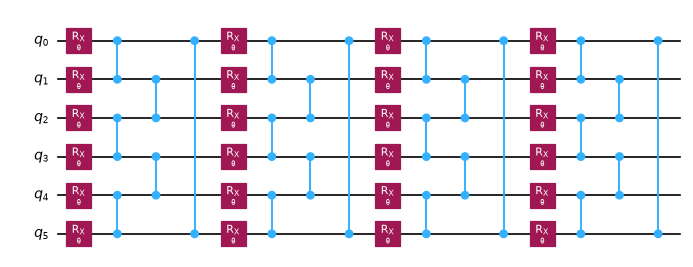

In [1]:
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

num_qubits, trotter_steps = 6, 4
ring = [(q, (q + 1) % num_qubits) for q in range(num_qubits)]
theta = Parameter("θ")

circuit = QuantumCircuit(num_qubits)
for _ in range(trotter_steps):
    circuit.rx(theta, range(num_qubits))
    for edge in ring[0::2] + ring[1::2]:  # even edges, then odd edges
        circuit.cz(*edge)

magnetization = SparsePauliOp.from_sparse_list([("Z", [0], 1.0)], num_qubits)
thetas = np.linspace(0, np.pi / 6, 7).reshape(-1, 1)

circuit.draw("mpl", fold=-1, scale=0.6)

### 2. Stratify the circuit into unique layers

`find_unique_layers` boxes the circuit and returns one instance of every structurally distinct box. Each entangling box carries a `Twirl` annotation (Pauli twirling turns the device noise into Pauli noise) and an `InjectNoise` annotation whose `ref` names the noise model to inject. The `Tag` annotation is a hash of the box's content; it is only for the simulator, which uses it to find where to attach the hidden noise. Only these two layers need to be learned, no matter how many Trotter steps the circuit has.

Twirl(group='pauli', dressing='left', decomposition='rzsx')
InjectNoise(ref='r046A', modifier_ref='', site='after')
Tag(ref='t046')

Twirl(group='pauli', dressing='left', decomposition='rzsx')
InjectNoise(ref='r6a4A', modifier_ref='', site='after')
Tag(ref='t6a4')



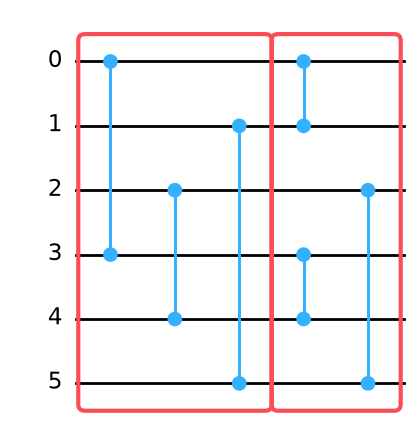

In [2]:
from qiskit_mitigation import PEC
from samplomatic import InjectNoise, Tag
from samplomatic.utils import get_annotation

boxing_options = {"add_tags": "unique_box"}  # a Tag per distinct box, for the simulator
layers = [box for box in PEC().find_unique_layers(circuit, boxing_options) if get_annotation(box.operation, InjectNoise)]
tags = {get_annotation(box.operation, InjectNoise).ref: get_annotation(box.operation, Tag).ref for box in layers}

for box in layers:
    print(*box.operation.annotations, sep="\n", end="\n\n")
QuantumCircuit.from_instructions(layers).draw("mpl")

### 3. Learn the noise

A hidden Pauli-Lindblad model with random rates on every qubit and every coupled pair is attached to each layer; the `AerExecutor` injects it after the layer whenever a tagged box is executed. `NoiseLearner` then runs the standard Pauli-fidelity experiment (each layer repeated `fragment_depths` times, twirled and measured in every needed basis) and fits a model per `InjectNoise` reference. The scatter compares every learned rate with the truth. The spread does not shrink with more learning shots: it comes mostly from the degeneracies of layer noise learning, where some pairs of generators can only be learned as a sum. The channel as a whole is still learned correctly, which is all PEC needs.

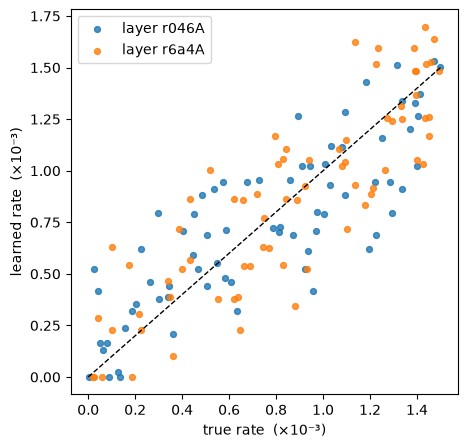

In [3]:
import matplotlib.pyplot as plt
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import PauliLindbladMap
from qiskit_aer import AerSimulator
from qiskit_noise_learning.aer_executor import AerExecutor
from qiskit_noise_learning.noise_learner import LearningOptions, NoiseLearner

# the hidden truth: random rates on every weight-1 and every coupled weight-2 Pauli generator
rng = np.random.default_rng(0)
generators = [(p, [q]) for q in range(num_qubits) for p in "XYZ"] + [(p + s, e) for e in ring for p in "XYZ" for s in "XYZ"]
true_noise = {ref: PauliLindbladMap.from_sparse_list([(*g, rng.uniform(0, 1.5e-3)) for g in generators], num_qubits) for ref in tags}
device = AerExecutor(AerSimulator(method="statevector"), noise_dict={tags[ref]: noise for ref, noise in true_noise.items()}, root_seed=0, warn_absent=False)

# learn it back from the layers alone
backend = GenericBackendV2(num_qubits, basis_gates=["rz", "sx", "x", "cz"], coupling_map=ring)
options = LearningOptions(fragment_depths=[0, 2, 4, 8, 16], num_randomizations=32, shots_per_randomizations=128)
learned_noise = NoiseLearner(backend, options, executor=device).run(layers).result().to_dict()

rates = lambda noise: {(pauli, tuple(qubits)): 1e3 * rate for pauli, qubits, rate in noise.to_sparse_list()}
plt.figure(figsize=(5, 5))
for ref in tags:
    true, learned = rates(true_noise[ref]), rates(learned_noise[ref])
    plt.scatter([true[g] for g in true], [learned[g] for g in true], s=18, alpha=0.8, label=f"layer {ref}")
plt.plot([0, 1.5], [0, 1.5], "k--", lw=1)
plt.xlabel("true rate  (×10⁻³)"), plt.ylabel("learned rate  (×10⁻³)"), plt.legend();

### 4. Sample

Both runs go into one `QuantumProgram` and execute together on the noisy device. The plain `MitigationTask` samples the twirled circuit as is; `PEC.prepare` additionally injects the inverse of the learned noise and scales its number of randomizations by the sampling overhead $\gamma^2$. The inverse noise is sampled once per randomization, so PEC's statistical error is set by the number of randomizations rather than by the shots; we therefore use many randomizations with few shots each.

In [4]:
from qiskit_ibm_runtime import QuantumProgram
from qiskit_mitigation import MitigationTask

program = QuantumProgram(shots=16)
sampling = dict(num_randomizations=500, shots_per_randomization=program.shots, broadcast_obs_and_params=True, quantum_program=program)

tasks = {"unmitigated": MitigationTask(), "PEC": PEC()}
tasks["unmitigated"].prepare(circuit, [magnetization], thetas, boxing_options, **sampling)
tasks["PEC"].prepare(circuit, [magnetization], thetas, boxing_options, noise_maps=learned_noise, **sampling)
result = device.run(program).result()

print(f"PEC: γ = {tasks['PEC'].gamma:.2f}, so its 500 randomizations are scaled by γ² = {tasks['PEC'].gamma**2:.1f} to {program.items[1].shape[0]}")

PEC: γ = 2.53, so its 500 randomizations are scaled by γ² = 6.4 to 3190


### 5. Reconstruct the expectation values

`postprocess` averages the shots of every randomization with its quasi-probability sign and rescales by $\gamma$. The error bars are the standard error over randomizations. The unmitigated magnetization is biased towards zero, while PEC recovers the exact curve within its (larger) error bars: the price of an unbiased estimate is the $\gamma^2$ sampling overhead.

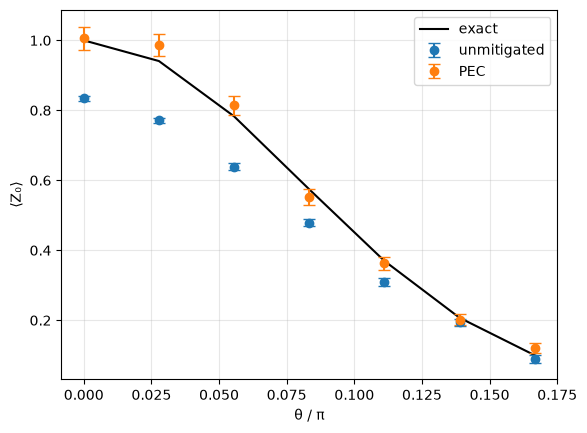

In [5]:
from qiskit.quantum_info import Statevector

exact = [Statevector(circuit.assign_parameters(t)).expectation_value(magnetization).real for t in thetas]

plt.plot(thetas / np.pi, exact, "k-", label="exact")
for item, (label, task) in enumerate(tasks.items()):
    data = task.postprocess(result[item]).data
    plt.errorbar(thetas / np.pi, data.evs.ravel(), data.twirl_stds.ravel(), fmt="o", capsize=4, label=label)
plt.xlabel("θ / π"), plt.ylabel("⟨Z₀⟩"), plt.legend(), plt.grid(alpha=0.3);